<a href="https://colab.research.google.com/github/Adasyam31494/Neural-Networks-and-Deep-Learning/blob/main/GAN_VAE_MNIST_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Reshape, LeakyReLU, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers
import os

os.makedirs("gan_images", exist_ok=True)
os.makedirs("vae_images", exist_ok=True)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
Test images shape: (10000, 28, 28)


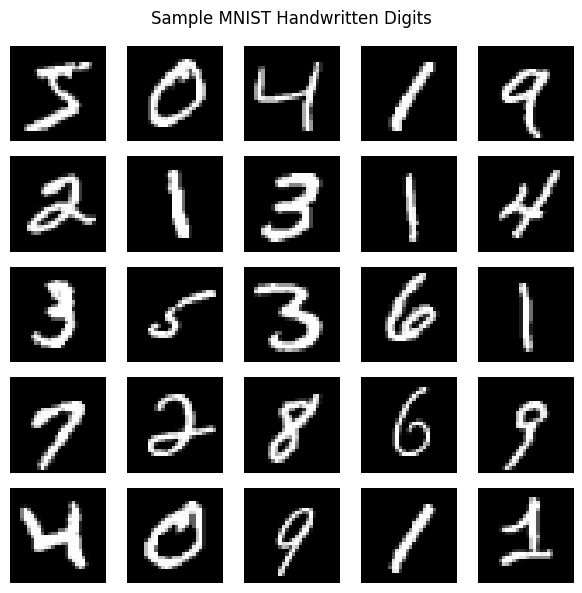

In [4]:
# Load MNIST dataset
(x_train, _), (x_test, _) = mnist.load_data()

print("Training images shape:", x_train.shape)
print("Test images shape:", x_test.shape)

# Show sample MNIST images
plt.figure(figsize=(6, 6))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.axis("off")

plt.suptitle("Sample MNIST Handwritten Digits")
plt.tight_layout()
plt.savefig("mnist_sample_digits.png")
plt.show()

In [5]:
# Normalize images from [0, 255] to [-1, 1] for GAN
x_train_gan = (x_train.astype("float32") - 127.5) / 127.5

# Add channel dimension: (60000, 28, 28, 1)
x_train_gan = np.expand_dims(x_train_gan, axis=-1)

img_shape = (28, 28, 1)
latent_dim = 100

print("GAN training data shape:", x_train_gan.shape)

GAN training data shape: (60000, 28, 28, 1)


In [6]:
optimizer = Adam(learning_rate=0.0002, beta_1=0.5)

def build_generator():
    model = Sequential(name="Generator")

    model.add(Dense(256, input_dim=latent_dim))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(BatchNormalization())

    model.add(Dense(512))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(BatchNormalization())

    model.add(Dense(1024))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(BatchNormalization())

    model.add(Dense(28 * 28 * 1, activation="tanh"))
    model.add(Reshape(img_shape))

    return model

def build_discriminator():
    model = Sequential(name="Discriminator")

    model.add(Flatten(input_shape=img_shape))
    model.add(Dense(512))
    model.add(LeakyReLU(negative_slope=0.2))

    model.add(Dense(256))
    model.add(LeakyReLU(negative_slope=0.2))

    model.add(Dense(1, activation="sigmoid"))

    return model

generator = build_generator()
discriminator = build_discriminator()

discriminator.compile(
    loss="binary_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)

generator.summary()
discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       803,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,493,520 (5.70 MB)

 Trainable params: 1,489,936 (5.68 MB)

...

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Freeze discriminator when training the combined GAN
discriminator.trainable = False

z = tf.keras.Input(shape=(latent_dim,))
generated_image = generator(z)
validity = discriminator(generated_image)

gan = tf.keras.Model(z, validity)
gan.compile(loss="binary_crossentropy", optimizer=optimizer)

print("Combined GAN model created successfully.")

Combined GAN model created successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 500 | D loss: 2.4275 | D accuracy: 49.20% | G loss: 0.0279
Epoch 1000 | D loss: 3.0531 | D accuracy: 49.11% | G loss: 0.0145


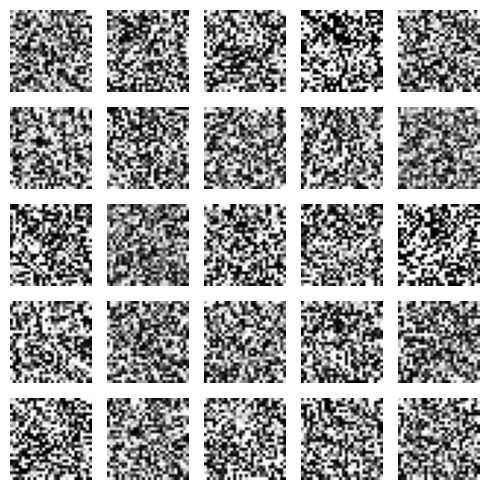

Saved: gan_images/gan_epoch_1000.png
Epoch 1500 | D loss: 3.3949 | D accuracy: 49.10% | G loss: 0.0098
Epoch 2000 | D loss: 3.6342 | D accuracy: 49.06% | G loss: 0.0074


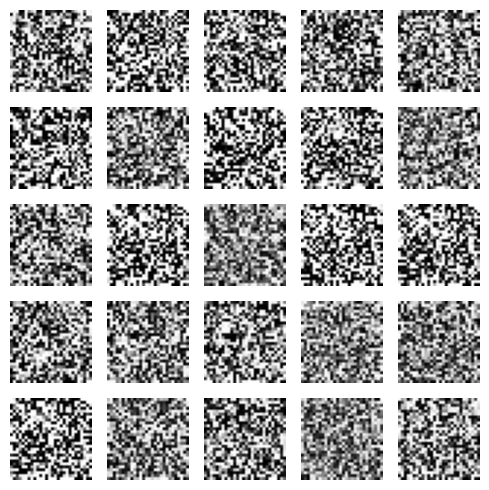

Saved: gan_images/gan_epoch_2000.png
Epoch 2500 | D loss: 3.8213 | D accuracy: 49.04% | G loss: 0.0060
Epoch 3000 | D loss: 3.9760 | D accuracy: 49.03% | G loss: 0.0050


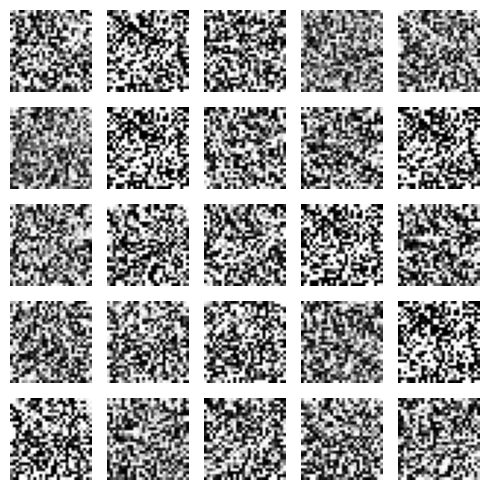

Saved: gan_images/gan_epoch_3000.png
Epoch 3500 | D loss: 4.1101 | D accuracy: 49.03% | G loss: 0.0043
Epoch 4000 | D loss: 4.2291 | D accuracy: 49.03% | G loss: 0.0038


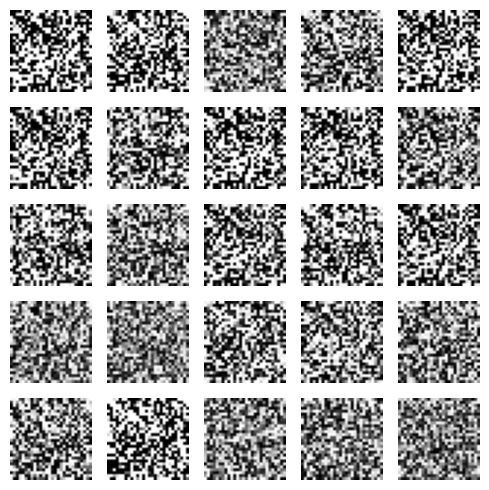

Saved: gan_images/gan_epoch_4000.png
Epoch 4500 | D loss: 4.3361 | D accuracy: 49.02% | G loss: 0.0034
Epoch 5000 | D loss: 4.4351 | D accuracy: 49.03% | G loss: 0.0030


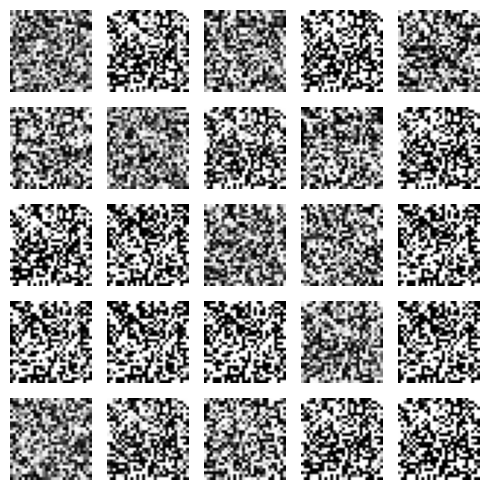

Saved: gan_images/gan_epoch_5000.png


In [8]:
def save_gan_images(epoch):
    noise = np.random.normal(0, 1, (25, latent_dim))
    generated = generator.predict(noise, verbose=0)

    # Convert from [-1, 1] to [0, 1]
    generated = 0.5 * generated + 0.5

    plt.figure(figsize=(5, 5))
    for i in range(25):
        plt.subplot(5, 5, i + 1)
        plt.imshow(generated[i, :, :, 0], cmap="gray")
        plt.axis("off")

    plt.tight_layout()
    file_name = f"gan_images/gan_epoch_{epoch}.png"
    plt.savefig(file_name)
    plt.show()
    print("Saved:", file_name)

def train_gan(epochs=5000, batch_size=64, save_interval=1000):
    half_batch = batch_size // 2

    for epoch in range(1, epochs + 1):

        # Train discriminator with real images
        idx = np.random.randint(0, x_train_gan.shape[0], half_batch)
        real_images = x_train_gan[idx]

        # Train discriminator with fake images
        noise = np.random.normal(0, 1, (half_batch, latent_dim))
        fake_images = generator.predict(noise, verbose=0)

        real_labels = np.ones((half_batch, 1))
        fake_labels = np.zeros((half_batch, 1))

        d_loss_real = discriminator.train_on_batch(real_images, real_labels)
        d_loss_fake = discriminator.train_on_batch(fake_images, fake_labels)
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

        # Train generator
        noise = np.random.normal(0, 1, (batch_size, latent_dim))
        valid_labels = np.ones((batch_size, 1))

        g_loss = gan.train_on_batch(noise, valid_labels)

        # Print progress
        if epoch % 500 == 0:
            print(
                f"Epoch {epoch} | "
                f"D loss: {d_loss[0]:.4f} | "
                f"D accuracy: {d_loss[1] * 100:.2f}% | "
                f"G loss: {float(g_loss):.4f}"
            )

        # Save generated images
        if epoch % save_interval == 0:
            save_gan_images(epoch)

train_gan(epochs=5000, batch_size=64, save_interval=1000)

In [9]:
# Normalize images from [0, 255] to [0, 1] for VAE
x_train_vae = x_train.astype("float32") / 255.0
x_test_vae = x_test.astype("float32") / 255.0

# Add channel dimension
x_train_vae = np.expand_dims(x_train_vae, -1)
x_test_vae = np.expand_dims(x_test_vae, -1)

print("VAE training data shape:", x_train_vae.shape)
print("VAE test data shape:", x_test_vae.shape)

VAE training data shape: (60000, 28, 28, 1)
VAE test data shape: (10000, 28, 28, 1)


In [10]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [11]:
latent_dim = 2

# Encoder
encoder_inputs = keras.Input(shape=(28, 28, 1))

x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])

encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# Decoder
latent_inputs = keras.Input(shape=(latent_dim,))

x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)

decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)

decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")

encoder.summary()
decoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │        320 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 3136)      │          0 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 16)        │     50,192 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2)
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + kl_loss

        gradients = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss
        }

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())

history = vae.fit(
    x_train_vae,
    epochs=100,
    batch_size=128
)

Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 166ms/step - kl_loss: 3.5040 - loss: 198.3341 - reconstruction_loss: 194.8301
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 169ms/step - kl_loss: 3.1187 - loss: 185.2345 - reconstruction_loss: 182.1158
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 173ms/step - kl_loss: 2.9200 - loss: 183.8574 - reconstruction_loss: 180.9374
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 175ms/step - kl_loss: 3.2815 - loss: 182.8468 - reconstruction_loss: 179.5653
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 173ms/step - kl_loss: 3.0385 - loss: 186.0326 - reconstruction_loss: 182.9941
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 173ms/step - kl_loss: 3.4698 - loss: 175.7766 - reconstruction_loss: 172.3068
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 85s 180ms/step - kl_loss: 3.6846 - loss: 168.9322 - reconstruction_loss: 165.2476
Epoch 8/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 140s 175ms/step - kl_loss: 3.8158 - loss: 171.0018 - reconstruction_loss: 167.1860
Epoch 9/100
469

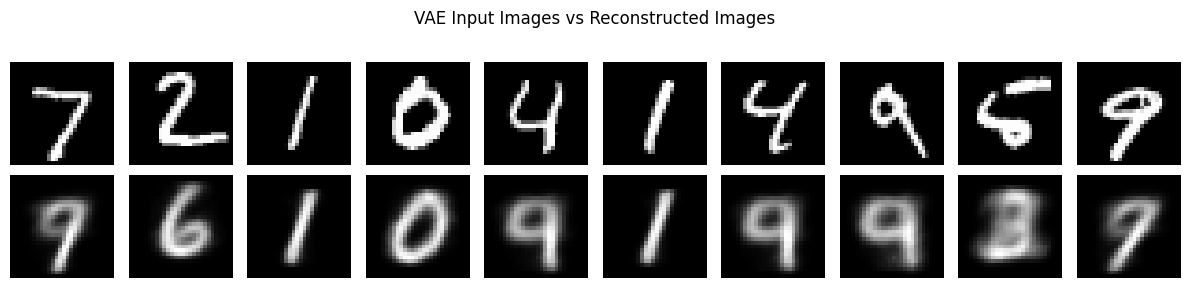

In [13]:
def show_reconstructions():
    z_mean, z_log_var, z = encoder.predict(x_test_vae[:10], verbose=0)
    reconstructed = decoder.predict(z, verbose=0)

    plt.figure(figsize=(12, 3))

    for i in range(10):
        # Original input image
        plt.subplot(2, 10, i + 1)
        plt.imshow(x_test_vae[i].reshape(28, 28), cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel("Input")

        # Reconstructed image
        plt.subplot(2, 10, i + 11)
        plt.imshow(reconstructed[i].reshape(28, 28), cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel("Output")

    plt.suptitle("VAE Input Images vs Reconstructed Images")
    plt.tight_layout()
    plt.savefig("vae_images/vae_input_vs_reconstruction.png")
    plt.show()

show_reconstructions()

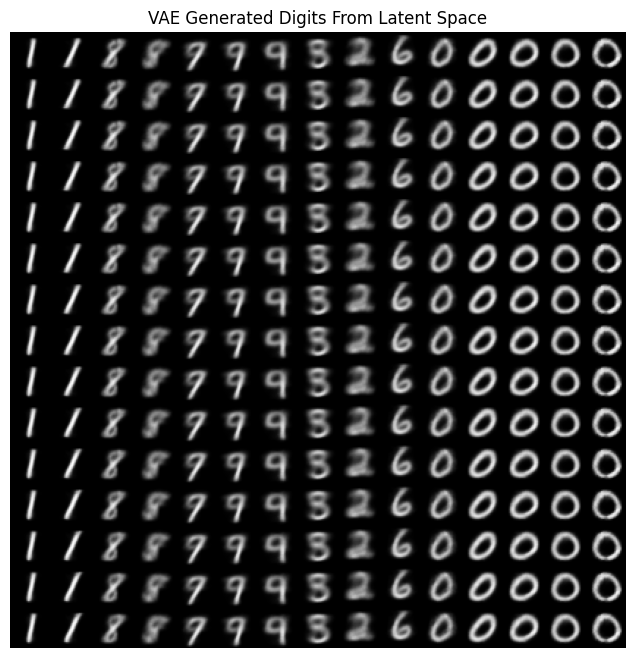

In [14]:
def generate_vae_digits():
    n = 15
    digit_size = 28
    figure = np.zeros((digit_size * n, digit_size * n))

    grid_x = np.linspace(-2, 2, n)
    grid_y = np.linspace(-2, 2, n)

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.array([[xi, yi]])
            generated = decoder.predict(z_sample, verbose=0)
            digit = generated[0].reshape(28, 28)

            figure[
                i * digit_size:(i + 1) * digit_size,
                j * digit_size:(j + 1) * digit_size
            ] = digit

    plt.figure(figsize=(8, 8))
    plt.imshow(figure, cmap="gray")
    plt.axis("off")
    plt.title("VAE Generated Digits From Latent Space")
    plt.savefig("vae_images/vae_generated_digits.png")
    plt.show()

generate_vae_digits()

Epoch 500 | D loss: 0.2081 | D accuracy: 90.76% | G loss: 4.3157
Epoch 1000 | D loss: 0.4175 | D accuracy: 76.82% | G loss: 2.5540
Epoch 1500 | D loss: 0.4664 | D accuracy: 76.36% | G loss: 2.0467
Epoch 2000 | D loss: 0.4851 | D accuracy: 76.22% | G loss: 1.8191


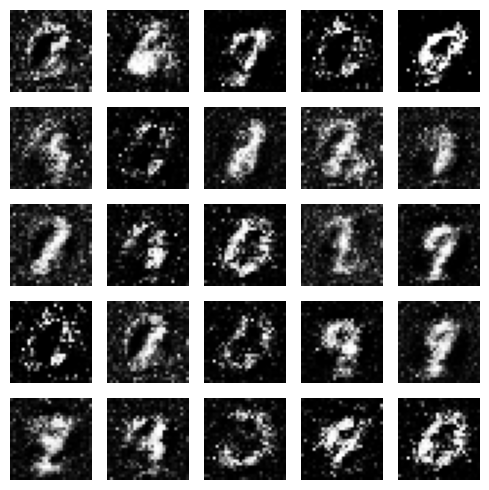

Saved: gan_images/gan_epoch_2000.png
Epoch 2500 | D loss: 0.4974 | D accuracy: 75.69% | G loss: 1.6834
Epoch 3000 | D loss: 0.5075 | D accuracy: 75.06% | G loss: 1.5898
Epoch 3500 | D loss: 0.5183 | D accuracy: 74.29% | G loss: 1.5148
Epoch 4000 | D loss: 0.5279 | D accuracy: 73.59% | G loss: 1.4544


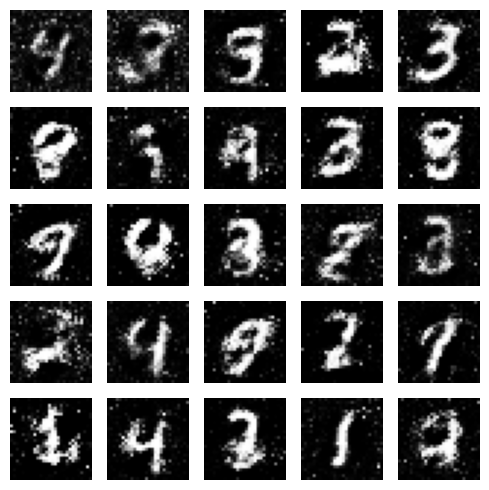

Saved: gan_images/gan_epoch_4000.png
Epoch 4500 | D loss: 0.5370 | D accuracy: 72.83% | G loss: 1.4057
Epoch 5000 | D loss: 0.5465 | D accuracy: 71.99% | G loss: 1.3615
Epoch 5500 | D loss: 0.5558 | D accuracy: 71.13% | G loss: 1.3228
Epoch 6000 | D loss: 0.5644 | D accuracy: 70.29% | G loss: 1.2892


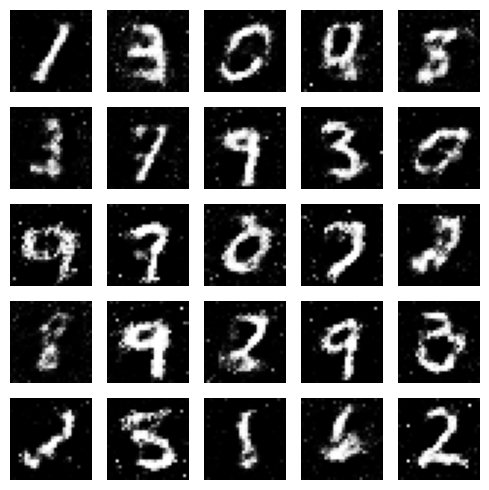

Saved: gan_images/gan_epoch_6000.png
Epoch 6500 | D loss: 0.5723 | D accuracy: 69.51% | G loss: 1.2597
Epoch 7000 | D loss: 0.5793 | D accuracy: 68.76% | G loss: 1.2337
Epoch 7500 | D loss: 0.5858 | D accuracy: 68.05% | G loss: 1.2104
Epoch 8000 | D loss: 0.5915 | D accuracy: 67.41% | G loss: 1.1899


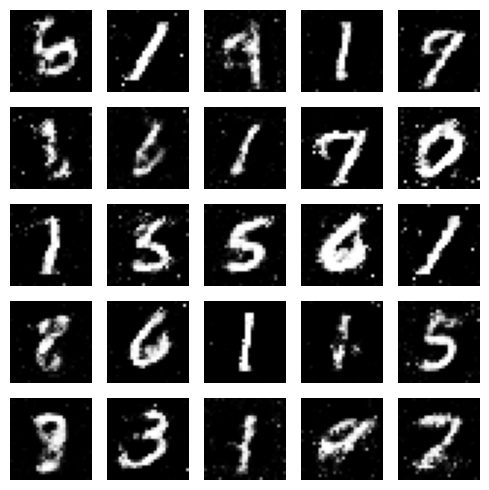

Saved: gan_images/gan_epoch_8000.png
Epoch 8500 | D loss: 0.5966 | D accuracy: 66.84% | G loss: 1.1713
Epoch 9000 | D loss: 0.6013 | D accuracy: 66.31% | G loss: 1.1546
Epoch 9500 | D loss: 0.6055 | D accuracy: 65.84% | G loss: 1.1397
Epoch 10000 | D loss: 0.6094 | D accuracy: 65.39% | G loss: 1.1261


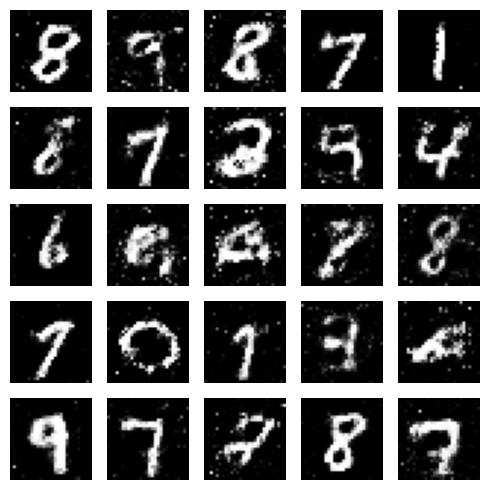

Saved: gan_images/gan_epoch_10000.png


In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Reshape, LeakyReLU, BatchNormalization
from tensorflow.keras.optimizers import Adam

os.makedirs("gan_images", exist_ok=True)

# Load MNIST
(x_train, _), (_, _) = mnist.load_data()

# Normalize images to [-1, 1]
x_train = (x_train.astype("float32") - 127.5) / 127.5
x_train = np.expand_dims(x_train, axis=-1)

GAN_LATENT_DIM = 100
img_shape = (28, 28, 1)

# Build Generator
def build_generator():
    model = Sequential(name="Generator")
    model.add(Dense(256, input_shape=(GAN_LATENT_DIM,)))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(BatchNormalization())

    model.add(Dense(512))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(BatchNormalization())

    model.add(Dense(1024))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(BatchNormalization())

    model.add(Dense(28 * 28 * 1, activation="tanh"))
    model.add(Reshape(img_shape))
    return model

# Build Discriminator
def build_discriminator():
    model = Sequential(name="Discriminator")
    model.add(Flatten(input_shape=img_shape))
    model.add(Dense(512))
    model.add(LeakyReLU(negative_slope=0.2))

    model.add(Dense(256))
    model.add(LeakyReLU(negative_slope=0.2))

    model.add(Dense(1, activation="sigmoid"))
    return model

generator = build_generator()
discriminator = build_discriminator()

d_optimizer = Adam(learning_rate=0.0002, beta_1=0.5)
g_optimizer = Adam(learning_rate=0.0002, beta_1=0.5)

discriminator.compile(
    loss="binary_crossentropy",
    optimizer=d_optimizer,
    metrics=["accuracy"]
)

# Build combined GAN
discriminator.trainable = False

z = tf.keras.Input(shape=(GAN_LATENT_DIM,))
fake_img = generator(z)
validity = discriminator(fake_img)

gan = tf.keras.Model(z, validity)
gan.compile(loss="binary_crossentropy", optimizer=g_optimizer)

# Save generated images
def save_gan_images(epoch):
    noise = np.random.normal(0, 1, (25, GAN_LATENT_DIM))
    generated = generator.predict(noise, verbose=0)

    generated = 0.5 * generated + 0.5

    plt.figure(figsize=(5, 5))
    for i in range(25):
        plt.subplot(5, 5, i + 1)
        plt.imshow(generated[i, :, :, 0], cmap="gray")
        plt.axis("off")

    plt.tight_layout()
    file_name = f"gan_images/gan_epoch_{epoch}.png"
    plt.savefig(file_name)
    plt.show()
    print("Saved:", file_name)

# Train GAN
def train_gan(epochs=10000, batch_size=64, save_interval=2000):
    half_batch = batch_size // 2

    for epoch in range(1, epochs + 1):

        # Train discriminator
        discriminator.trainable = True

        idx = np.random.randint(0, x_train.shape[0], half_batch)
        real_imgs = x_train[idx]

        noise = np.random.normal(0, 1, (half_batch, GAN_LATENT_DIM))
        fake_imgs = generator.predict(noise, verbose=0)

        real_labels = np.ones((half_batch, 1))
        fake_labels = np.zeros((half_batch, 1))

        d_loss_real = discriminator.train_on_batch(real_imgs, real_labels)
        d_loss_fake = discriminator.train_on_batch(fake_imgs, fake_labels)
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

        # Train generator
        discriminator.trainable = False

        noise = np.random.normal(0, 1, (batch_size, GAN_LATENT_DIM))
        valid_labels = np.ones((batch_size, 1))

        g_loss = gan.train_on_batch(noise, valid_labels)

        if epoch % 500 == 0:
            print(
                f"Epoch {epoch} | "
                f"D loss: {d_loss[0]:.4f} | "
                f"D accuracy: {d_loss[1] * 100:.2f}% | "
                f"G loss: {float(g_loss):.4f}"
            )

        if epoch % save_interval == 0:
            save_gan_images(epoch)

train_gan(epochs=10000, batch_size=64, save_interval=2000)